#  Model Training Analysis
**Full analysis of step logs, epoch logs, and fusion head logs**

Covers:
- Step-level training loss & gradient norms
- Epoch-level train vs val loss
- Validation metrics (accuracy, F1 macro, F1 real, F1 fake)
- Learning rate schedule
- Early stopping analysis
- Fusion head training
- Overfitting detection
- Summary report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f7',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BLUE   = '#378ADD'
GREEN  = '#1D9E75'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
AMBER  = '#BA7517'
PINK   = '#993556'
GRAY   = '#888780'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data

In [2]:
# ── Update these paths if needed ──────────────────────────────────────────────
STEP_LOG_PATH   = 'step_logs.csv'
EPOCH_LOG_PATH  = 'epoch_logs.csv'
FUSION_LOG_PATH = 'fusion_head_logs.csv'
# ──────────────────────────────────────────────────────────────────────────────

step_df   = pd.read_csv(STEP_LOG_PATH, parse_dates=['timestamp'])
epoch_df  = pd.read_csv(EPOCH_LOG_PATH, parse_dates=['timestamp'])
fusion_df = pd.read_csv(FUSION_LOG_PATH, parse_dates=['timestamp'])

# Clean step_df: drop eval rows (loss==0 at epoch boundaries)
step_df = step_df[step_df['loss'] > 0].copy()
step_df = step_df[step_df['learning_rate'] > 0].copy()
step_df.reset_index(drop=True, inplace=True)

print(f'Step log:   {len(step_df)} rows  |  epochs {step_df["epoch"].min():.2f} → {step_df["epoch"].max():.2f}')
print(f'Epoch log:  {len(epoch_df)} epochs')
print(f'Fusion log: {len(fusion_df)} epochs')
epoch_df

Step log:   180 rows  |  epochs 0.03 → 6.00
Epoch log:  6 epochs
Fusion log: 6 epochs


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro,val_f1_real,val_f1_fake,grad_norm,timestamp
0,1.0,0.028039,0.036015,0.990000,0.990000,0.990019,0.989981,4.099090,2026-03-24 18:36:15
1,2.0,0.019280,0.027715,0.992792,0.992792,0.992770,0.992814,1.203417,2026-03-24 19:00:53
2,3.0,0.006926,0.028267,0.994000,0.994000,0.993972,0.994027,2.622518,2026-03-24 19:25:31
3,4.0,0.006462,0.031078,0.994667,0.994667,0.994642,0.994691,0.023896,2026-03-24 19:50:09
4,5.0,0.001279,0.033142,0.995375,0.995375,0.995354,0.995396,0.011000,2026-03-24 20:14:46
5,6.0,0.002964,0.039685,0.994750,0.994750,0.994733,0.994767,0.001844,2026-03-24 20:39:25


## 2. Step-Level Training Loss

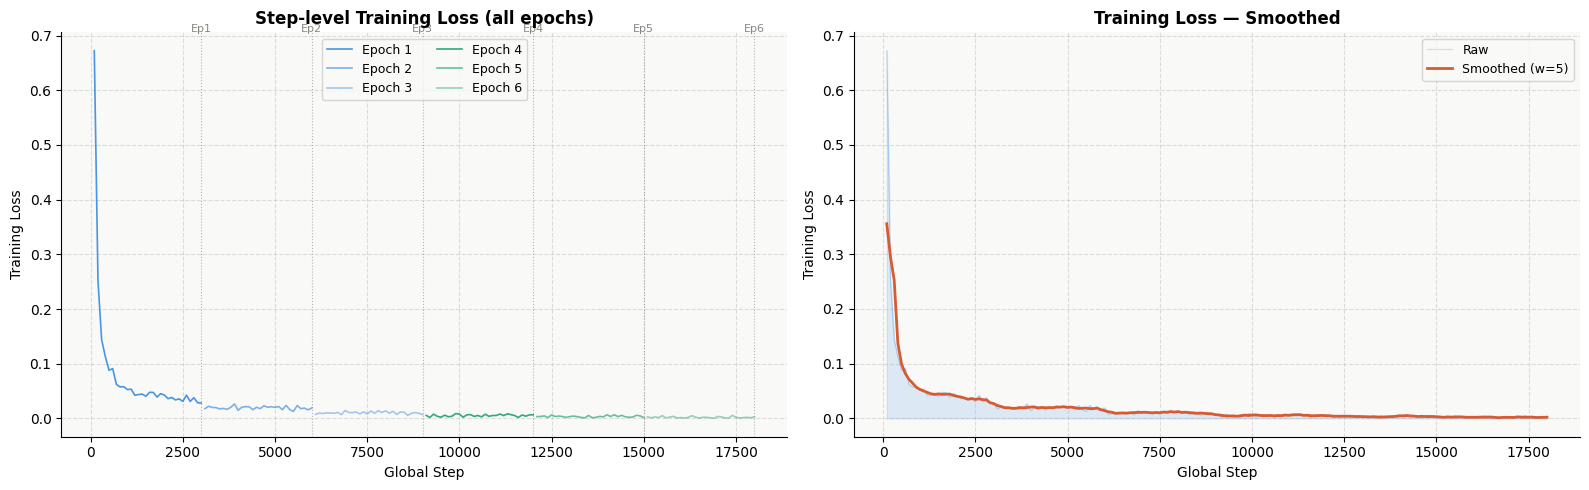

Final train loss: 0.00296
Min train loss:   0.00012 at step 16900


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw loss
ax = axes[0]
epoch_boundaries = [1, 2, 3, 4, 5, 6]
colors_map = {1: BLUE, 2: BLUE, 3: BLUE, 4: GREEN, 5: GREEN, 6: GREEN}
for e in epoch_boundaries:
    mask = (step_df['epoch'] > e-1) & (step_df['epoch'] <= e)
    subset = step_df[mask]
    alpha = 0.9 if e in [1, 4] else 0.65 if e in [2, 5] else 0.45
    ax.plot(subset['global_step'], subset['loss'],
            color=colors_map[e], alpha=alpha, linewidth=1.2, label=f'Epoch {e}')

for e in epoch_boundaries:
    step_at_boundary = step_df[step_df['epoch'].round(2) == float(e)]['global_step']
    if not step_at_boundary.empty:
        ax.axvline(step_at_boundary.iloc[0], color=GRAY, linewidth=0.8, linestyle=':', alpha=0.6)
        ax.text(step_at_boundary.iloc[0], ax.get_ylim()[1] if ax.get_ylim()[1] < 10 else 0.05,
                f'Ep{e}', fontsize=8, color=GRAY, ha='center')

ax.set_xlabel('Global Step')
ax.set_ylabel('Training Loss')
ax.set_title('Step-level Training Loss (all epochs)', fontweight='bold')
ax.legend(fontsize=9, ncol=2)

# Smoothed loss (rolling average)
ax2 = axes[1]
window = max(5, len(step_df)//60)
step_df['loss_smooth'] = step_df['loss'].rolling(window=window, min_periods=1, center=True).mean()
ax2.fill_between(step_df['global_step'], step_df['loss'], alpha=0.15, color=BLUE)
ax2.plot(step_df['global_step'], step_df['loss'], color=BLUE, alpha=0.25, linewidth=0.8, label='Raw')
ax2.plot(step_df['global_step'], step_df['loss_smooth'], color=CORAL, linewidth=2, label=f'Smoothed (w={window})')
ax2.set_xlabel('Global Step')
ax2.set_ylabel('Training Loss')
ax2.set_title('Training Loss — Smoothed', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_step_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final train loss: {step_df["loss"].iloc[-1]:.5f}')
print(f'Min train loss:   {step_df["loss"].min():.5f} at step {step_df.loc[step_df["loss"].idxmin(), "global_step"]}')

## 3. Learning Rate Schedule

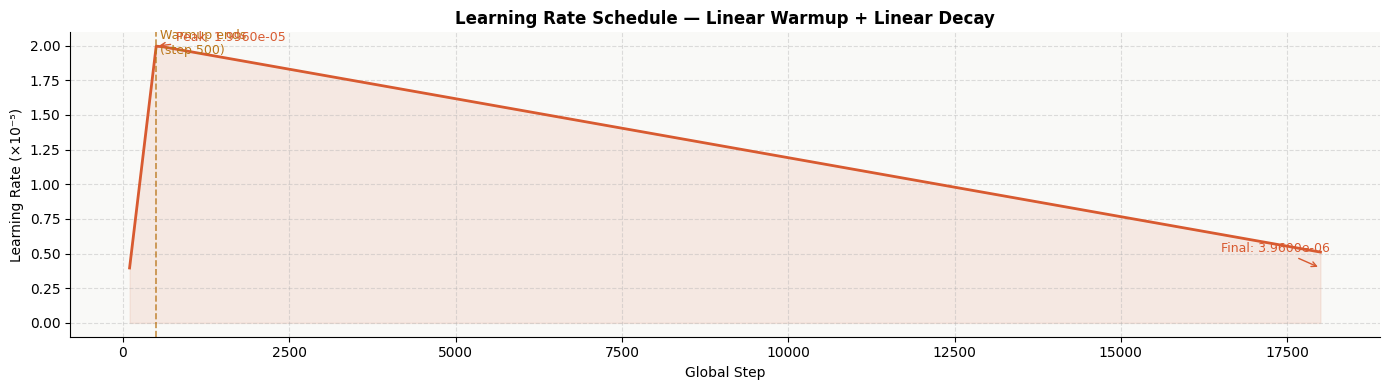

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(step_df['global_step'], step_df['learning_rate'] * 1e5, color=CORAL, linewidth=2)
ax.fill_between(step_df['global_step'], step_df['learning_rate'] * 1e5, alpha=0.1, color=CORAL)

# Annotate warmup and decay phases
warmup_end = step_df[step_df['learning_rate'] == step_df['learning_rate'].max()]['global_step'].iloc[0]
ax.axvline(warmup_end, color=AMBER, linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(warmup_end + 50, step_df['learning_rate'].max() * 1e5 * 0.97,
        f'Warmup ends\n(step {warmup_end})', fontsize=9, color=AMBER)

ax.set_xlabel('Global Step')
ax.set_ylabel('Learning Rate (×10⁻⁵)')
ax.set_title('Learning Rate Schedule — Linear Warmup + Linear Decay', fontweight='bold')

max_lr = step_df['learning_rate'].max()
min_lr = step_df['learning_rate'].min()
ax.annotate(f'Peak: {max_lr:.4e}', xy=(warmup_end, max_lr*1e5),
            xytext=(warmup_end+300, max_lr*1e5*1.02),
            fontsize=9, color=CORAL,
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1))
ax.annotate(f'Final: {min_lr:.4e}', xy=(step_df['global_step'].iloc[-1], min_lr*1e5),
            xytext=(step_df['global_step'].iloc[-1]-1500, min_lr*1e5*1.3),
            fontsize=9, color=CORAL,
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1))

plt.tight_layout()
plt.savefig('plot_lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Gradient Norm Analysis

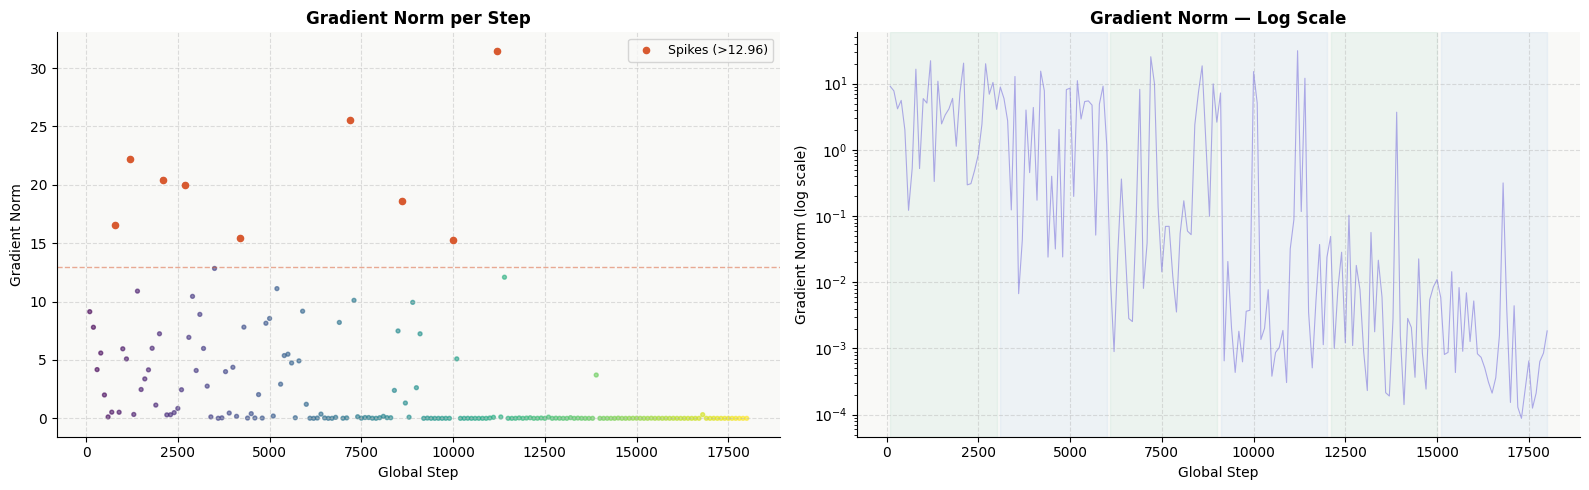

Max grad norm: 31.484 at step 11200
Grad norm spikes (>12.96): 9 occurrences

Grad norm by epoch:
  Epoch 1: mean=6.0549, max=22.2170, std=6.3518
  Epoch 2: mean=4.2450, max=15.4634, std=4.3539
  Epoch 3: mean=2.9178, max=25.5328, std=6.1080
  Epoch 4: mean=2.3833, max=31.4845, std=6.6370
  Epoch 5: mean=0.1358, max=3.7102, std=0.6755
  Epoch 6: mean=0.0127, max=0.3170, std=0.0576


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw grad norm
ax = axes[0]
ax.scatter(step_df['global_step'], step_df['grad_norm'],
           c=step_df['epoch'], cmap='viridis', s=8, alpha=0.6)
# Highlight spikes
spike_thresh = step_df['grad_norm'].quantile(0.95)
spikes = step_df[step_df['grad_norm'] > spike_thresh]
ax.scatter(spikes['global_step'], spikes['grad_norm'],
           color=CORAL, s=20, zorder=5, label=f'Spikes (>{spike_thresh:.2f})')
ax.axhline(spike_thresh, color=CORAL, linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Global Step')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradient Norm per Step', fontweight='bold')
ax.legend(fontsize=9)

# Log scale
ax2 = axes[1]
gn_clipped = step_df['grad_norm'].clip(lower=1e-6)
ax2.plot(step_df['global_step'], gn_clipped, color=PURPLE, linewidth=0.8, alpha=0.6)
ax2.set_yscale('log')

# Shade by epoch
for e in range(1, 7):
    start = step_df[step_df['epoch'] > e-1]['global_step'].iloc[0] if len(step_df[step_df['epoch'] > e-1]) > 0 else 0
    end_rows = step_df[step_df['epoch'].round(2) == float(e)]
    end = end_rows['global_step'].iloc[0] if not end_rows.empty else step_df['global_step'].iloc[-1]
    ax2.axvspan(start, end, alpha=0.06, color=[BLUE, GREEN][e % 2], label=f'Ep {e}' if e <= 2 else '')

ax2.set_xlabel('Global Step')
ax2.set_ylabel('Gradient Norm (log scale)')
ax2.set_title('Gradient Norm — Log Scale', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_grad_norm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Max grad norm: {step_df["grad_norm"].max():.3f} at step {step_df.loc[step_df["grad_norm"].idxmax(), "global_step"]}')
print(f'Grad norm spikes (>{spike_thresh:.2f}): {len(spikes)} occurrences')
# Show per-epoch grad norm stats
print('\nGrad norm by epoch:')
for e in range(1, 7):
    mask = (step_df['epoch'] > e-1) & (step_df['epoch'] <= e)
    gn = step_df.loc[mask, 'grad_norm']
    print(f'  Epoch {e}: mean={gn.mean():.4f}, max={gn.max():.4f}, std={gn.std():.4f}')

## 5. Epoch-Level: Train vs Val Loss

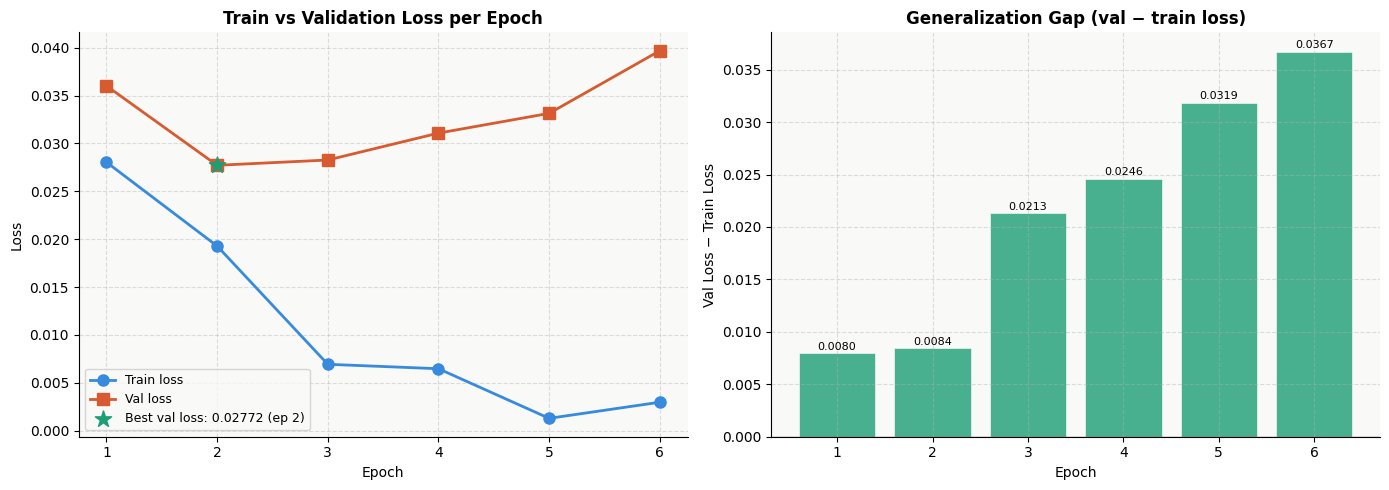

Best epoch:     2 (val loss = 0.02772)
Train/val gap at epoch 1: 0.00798
Train/val gap at epoch 6: 0.03672


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = epoch_df['epoch'].values

# Loss comparison
ax = axes[0]
ax.plot(epochs, epoch_df['train_loss'], 'o-', color=BLUE, linewidth=2,
        markersize=8, label='Train loss', zorder=5)
ax.plot(epochs, epoch_df['val_loss'], 's-', color=CORAL, linewidth=2,
        markersize=8, label='Val loss', zorder=5)

# Mark best val loss
best_idx = epoch_df['val_loss'].idxmin()
best_epoch = epoch_df.loc[best_idx, 'epoch']
best_vl = epoch_df.loc[best_idx, 'val_loss']
ax.scatter([best_epoch], [best_vl], color=GREEN, s=150, zorder=6,
           marker='*', label=f'Best val loss: {best_vl:.5f} (ep {int(best_epoch)})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Validation Loss per Epoch', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(epochs)

# Overfitting gap
ax2 = axes[1]
gap = epoch_df['val_loss'] - epoch_df['train_loss']
colors_bar = [GREEN if g > 0 else CORAL for g in gap]
bars = ax2.bar(epochs, gap, color=colors_bar, alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color=GRAY, linewidth=1)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Val Loss − Train Loss')
ax2.set_title('Generalization Gap (val − train loss)', fontweight='bold')
ax2.set_xticks(epochs)

for bar, val in zip(bars, gap):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{val:.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_epoch_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best epoch:     {int(best_epoch)} (val loss = {best_vl:.5f})')
print(f'Train/val gap at epoch 1: {gap.iloc[0]:.5f}')
print(f'Train/val gap at epoch 6: {gap.iloc[-1]:.5f}')

## 6. Validation Metrics

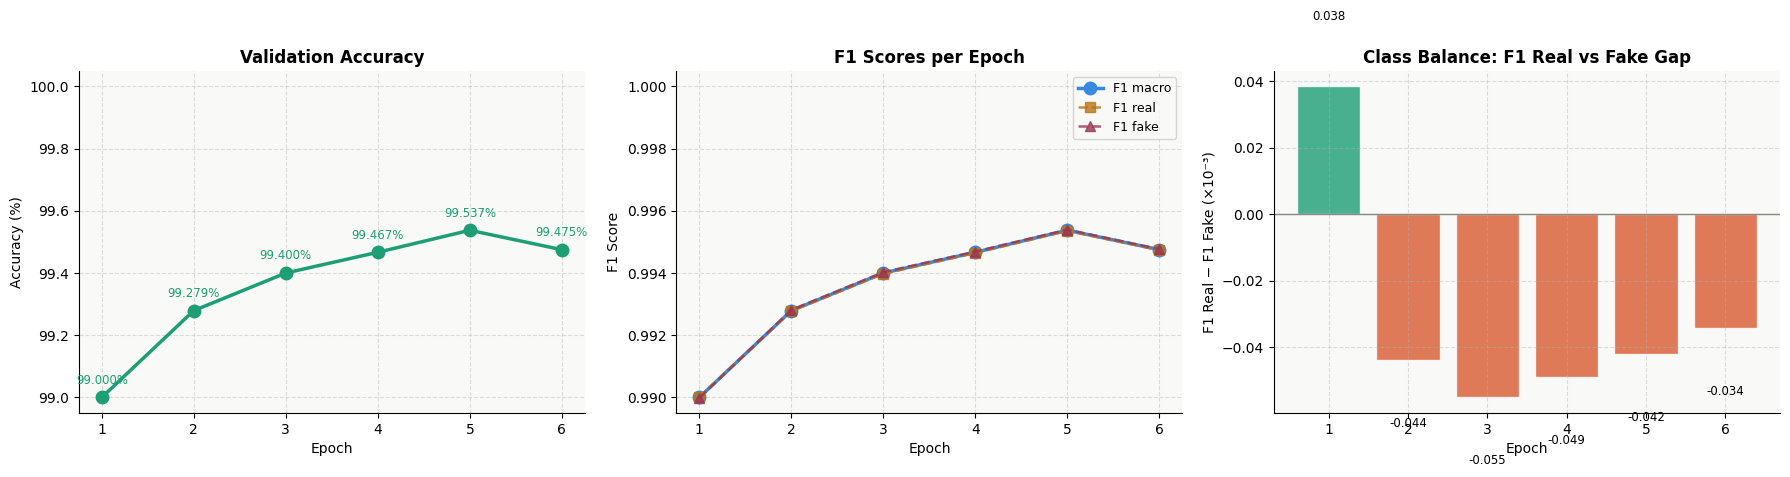

Peak accuracy:  99.5375% at epoch 5
Peak F1 macro:  0.995375 at epoch 5
Max F1 gap (real-fake): 0.0550×10⁻³  — model is well balanced


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
ax = axes[0]
ax.plot(epochs, epoch_df['val_accuracy'] * 100, 'o-', color=GREEN, linewidth=2.5, markersize=9)
for x, y in zip(epochs, epoch_df['val_accuracy'] * 100):
    ax.annotate(f'{y:.3f}%', (x, y), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8.5, color=GREEN)
ax.set_ylim(epoch_df['val_accuracy'].min()*100 - 0.05, 100.05)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Accuracy', fontweight='bold')
ax.set_xticks(epochs)

# F1 scores
ax2 = axes[1]
ax2.plot(epochs, epoch_df['val_f1_macro'], 'o-', color=BLUE, linewidth=2.5,
         markersize=9, label='F1 macro')
ax2.plot(epochs, epoch_df['val_f1_real'], 's--', color=AMBER, linewidth=1.8,
         markersize=7, alpha=0.8, label='F1 real')
ax2.plot(epochs, epoch_df['val_f1_fake'], '^--', color=PINK, linewidth=1.8,
         markersize=7, alpha=0.8, label='F1 fake')
ax2.set_ylim(epoch_df['val_f1_macro'].min() - 0.0005, 1.0005)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Scores per Epoch', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xticks(epochs)

# F1 real vs fake gap
ax3 = axes[2]
f1_diff = (epoch_df['val_f1_real'] - epoch_df['val_f1_fake']) * 1000  # in milliunits
colors_diff = [GREEN if d >= 0 else CORAL for d in f1_diff]
bars = ax3.bar(epochs, f1_diff, color=colors_diff, alpha=0.8, edgecolor='white')
ax3.axhline(0, color=GRAY, linewidth=1)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Real − F1 Fake (×10⁻³)')
ax3.set_title('Class Balance: F1 Real vs Fake Gap', fontweight='bold')
ax3.set_xticks(epochs)
for bar, val in zip(bars, f1_diff):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02 * (1 if val >= 0 else -1),
             f'{val:.3f}', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('plot_val_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

best_acc_idx = epoch_df['val_accuracy'].idxmax()
print(f'Peak accuracy:  {epoch_df.loc[best_acc_idx, "val_accuracy"]*100:.4f}% at epoch {int(epoch_df.loc[best_acc_idx, "epoch"])}')
print(f'Peak F1 macro:  {epoch_df["val_f1_macro"].max():.6f} at epoch {int(epoch_df.loc[epoch_df["val_f1_macro"].idxmax(), "epoch"])}')
print(f'Max F1 gap (real-fake): {f1_diff.abs().max():.4f}×10⁻³  — model is well balanced')

## 7. Early Stopping Analysis

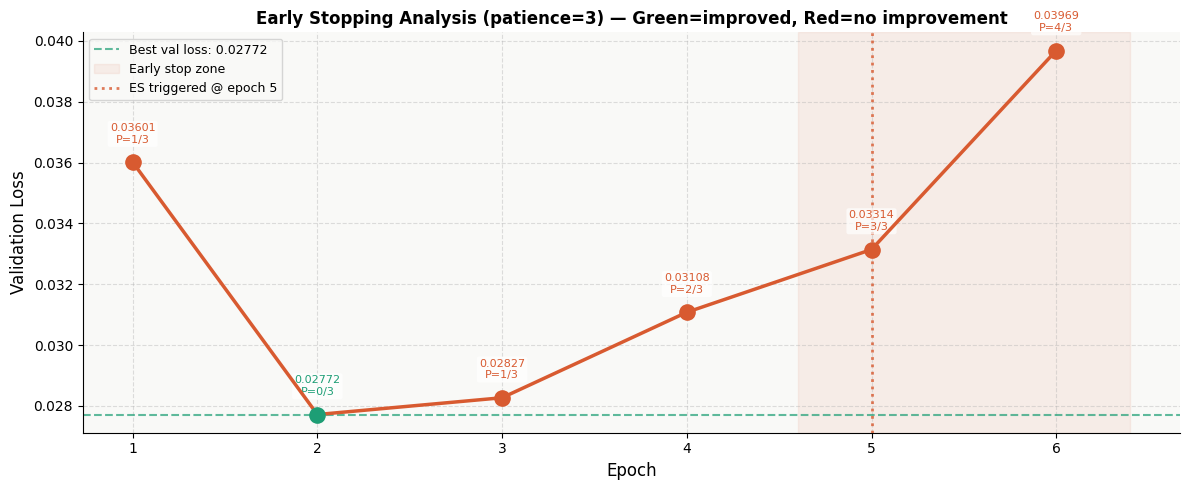

Patience counter by epoch:
  Epoch 1: ✗ no improve (patience 1/3)
  Epoch 2: ✓ improved
  Epoch 3: ✗ no improve (patience 1/3)
  Epoch 4: ✗ no improve (patience 2/3)
  Epoch 5: ✗ no improve (patience 3/3)
  Epoch 6: ✗ no improve (patience 4/3)


In [8]:
PATIENCE = 3

fig, ax = plt.subplots(figsize=(12, 5))

val_losses = epoch_df['val_loss'].values
best_vl = val_losses[0]
patience_counter = 0
patience_history = []
improved = []

for i, vl in enumerate(val_losses):
    if vl < best_vl:
        best_vl = vl
        patience_counter = 0
        improved.append(True)
    else:
        patience_counter += 1
        improved.append(False)
    patience_history.append(patience_counter)

# Plot val loss
ax.plot(epochs, val_losses, 'o-', color=CORAL, linewidth=2.5, markersize=10, zorder=5)

# Color markers by improvement
for i, (e, vl, imp) in enumerate(zip(epochs, val_losses, improved)):
    color = GREEN if imp else CORAL
    ax.scatter([e], [vl], color=color, s=120, zorder=6)
    ax.annotate(f'{vl:.5f}\nP={patience_history[i]}/{PATIENCE}',
                (e, vl), textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=8,
                color=GREEN if imp else CORAL,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

# Best val line
best_vl_final = val_losses.min()
ax.axhline(best_vl_final, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7,
           label=f'Best val loss: {best_vl_final:.5f}')

# Shade patience exhaustion region
if patience_history[-1] >= PATIENCE:
    stop_epoch = epochs[patience_history.index(PATIENCE)]
    ax.axvspan(stop_epoch - 0.4, epochs[-1] + 0.4, alpha=0.08, color=CORAL,
               label='Early stop zone')
    ax.axvline(stop_epoch, color=CORAL, linewidth=2, linestyle=':', alpha=0.8,
               label=f'ES triggered @ epoch {int(stop_epoch)}')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title(f'Early Stopping Analysis (patience={PATIENCE}) — Green=improved, Red=no improvement',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(epochs)

plt.tight_layout()
plt.savefig('plot_early_stopping.png', dpi=150, bbox_inches='tight')
plt.show()

print('Patience counter by epoch:')
for e, p, imp in zip(epochs, patience_history, improved):
    status = '✓ improved' if imp else f'✗ no improve (patience {p}/{PATIENCE})'
    print(f'  Epoch {int(e)}: {status}')

## 8. Fusion Head Analysis

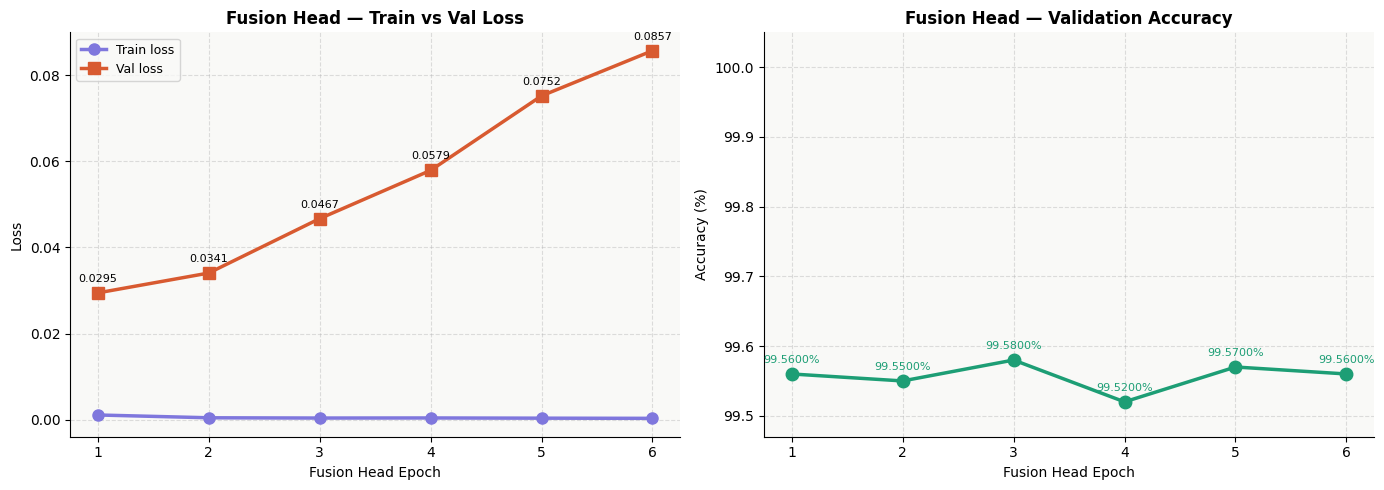

Fusion head best epoch: 1  (val loss=0.02945, acc=99.5600%)
Fusion head val loss divergence: 2.91× from ep1 to ep6


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fepochs = fusion_df['epoch'].values

# Loss
ax = axes[0]
ax.plot(fepochs, fusion_df['train_loss'], 'o-', color=PURPLE, linewidth=2.5,
        markersize=8, label='Train loss')
ax.plot(fepochs, fusion_df['val_loss'], 's-', color=CORAL, linewidth=2.5,
        markersize=8, label='Val loss')
for x, y in zip(fepochs, fusion_df['val_loss']):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)
ax.set_xlabel('Fusion Head Epoch')
ax.set_ylabel('Loss')
ax.set_title('Fusion Head — Train vs Val Loss', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(fepochs)

# Accuracy
ax2 = axes[1]
ax2.plot(fepochs, fusion_df['val_accuracy'] * 100, 'o-', color=GREEN, linewidth=2.5, markersize=9)
for x, y in zip(fepochs, fusion_df['val_accuracy'] * 100):
    ax2.annotate(f'{y:.4f}%', (x, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color=GREEN)
ax2.set_ylim(fusion_df['val_accuracy'].min()*100 - 0.05, 100.05)
ax2.set_xlabel('Fusion Head Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Fusion Head — Validation Accuracy', fontweight='bold')
ax2.set_xticks(fepochs)

plt.tight_layout()
plt.savefig('plot_fusion_head.png', dpi=150, bbox_inches='tight')
plt.show()

best_fep = fusion_df.loc[fusion_df['val_loss'].idxmin()]
print(f'Fusion head best epoch: {int(best_fep["epoch"])}  (val loss={best_fep["val_loss"]:.5f}, acc={best_fep["val_accuracy"]*100:.4f}%)')
print(f'Fusion head val loss divergence: {fusion_df["val_loss"].iloc[-1]/fusion_df["val_loss"].iloc[0]:.2f}× from ep1 to ep{len(fepochs)}')

## 9. Combined Overview Dashboard

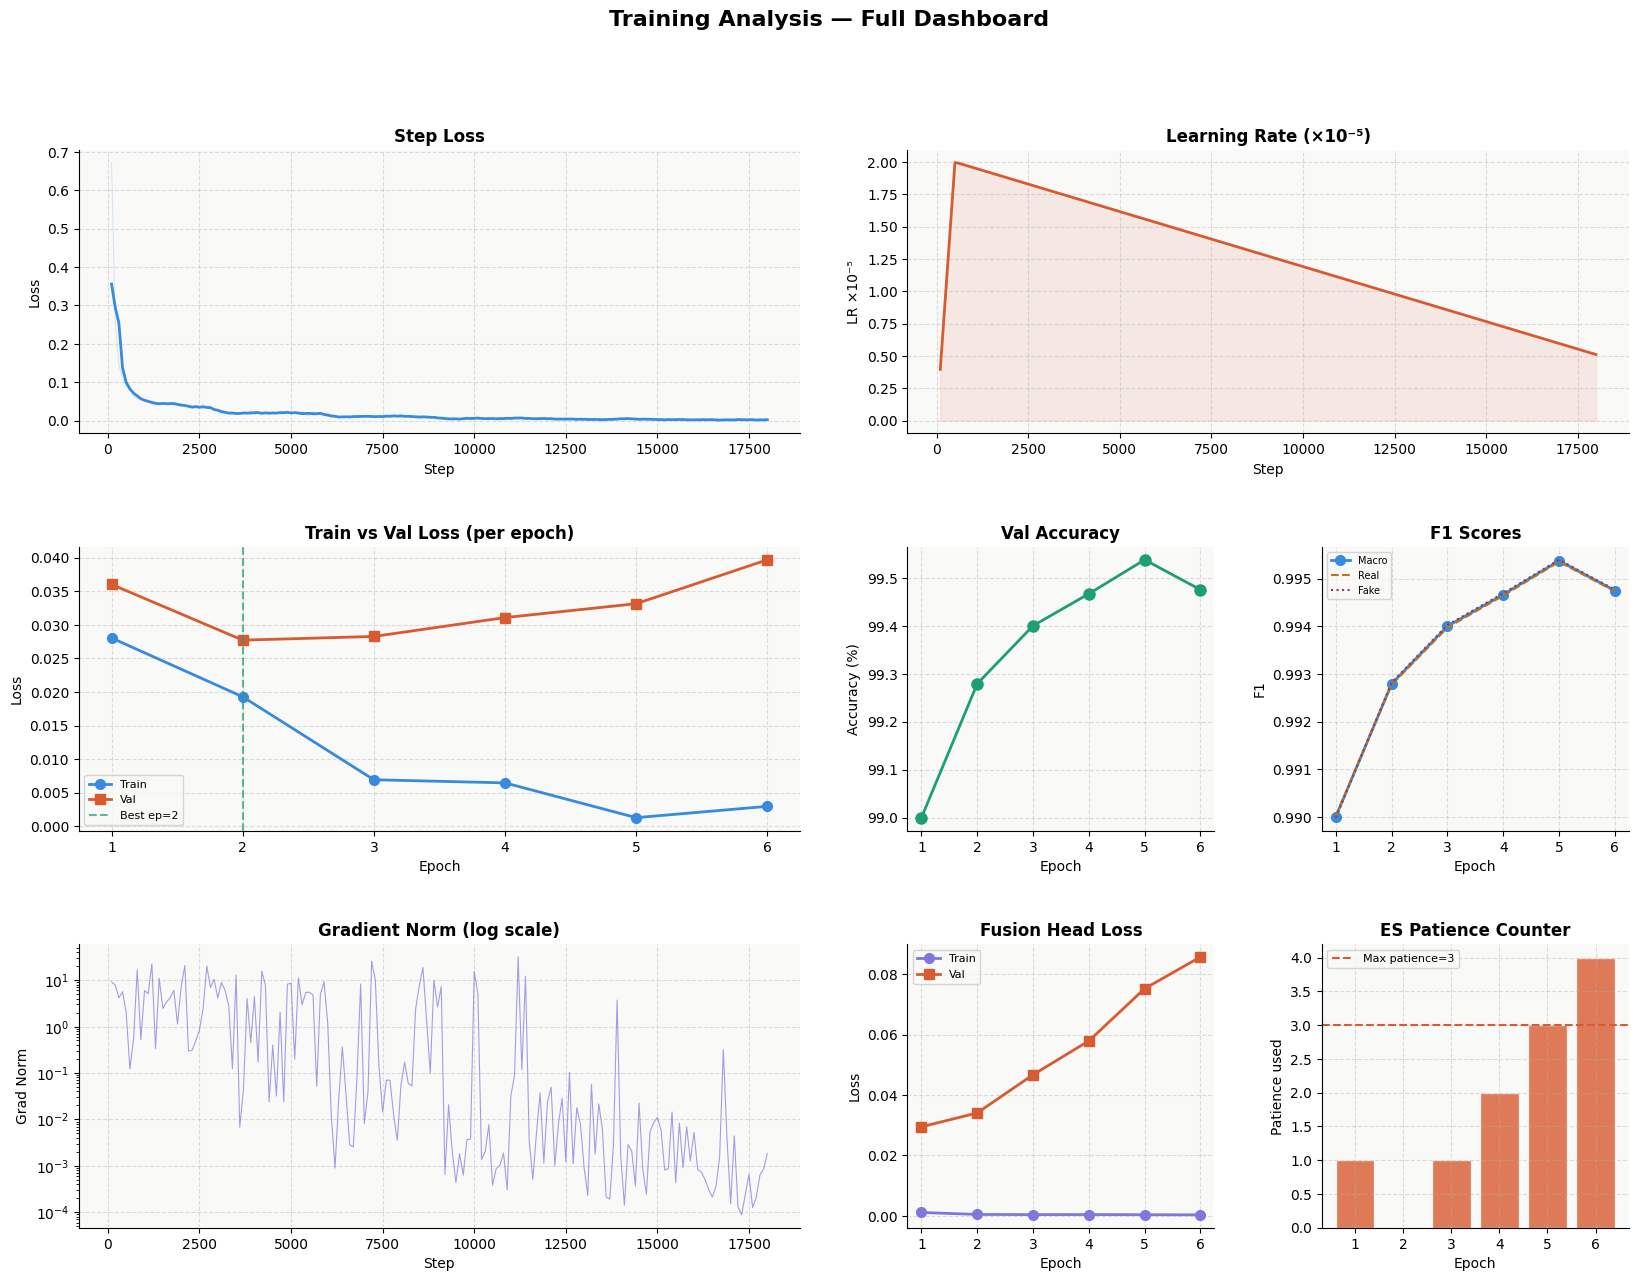

Dashboard saved as plot_dashboard.png ✓


In [10]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Training Analysis — Full Dashboard', fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.35)

# 1. Step loss (top-left, wide)
ax1 = fig.add_subplot(gs[0, :2])
window = max(5, len(step_df)//60)
step_df['loss_smooth'] = step_df['loss'].rolling(window=window, min_periods=1, center=True).mean()
ax1.plot(step_df['global_step'], step_df['loss'], color=BLUE, alpha=0.2, linewidth=0.7)
ax1.plot(step_df['global_step'], step_df['loss_smooth'], color=BLUE, linewidth=2, label='Smoothed')
ax1.set_title('Step Loss', fontweight='bold')
ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')

# 2. LR schedule (top-right, wide)
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(step_df['global_step'], step_df['learning_rate']*1e5, color=CORAL, linewidth=2)
ax2.fill_between(step_df['global_step'], step_df['learning_rate']*1e5, alpha=0.1, color=CORAL)
ax2.set_title('Learning Rate (×10⁻⁵)', fontweight='bold')
ax2.set_xlabel('Step'); ax2.set_ylabel('LR ×10⁻⁵')

# 3. Epoch train/val loss
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(epochs, epoch_df['train_loss'], 'o-', color=BLUE, linewidth=2, markersize=7, label='Train')
ax3.plot(epochs, epoch_df['val_loss'], 's-', color=CORAL, linewidth=2, markersize=7, label='Val')
best_ep = int(epoch_df.loc[epoch_df['val_loss'].idxmin(), 'epoch'])
ax3.axvline(best_ep, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7, label=f'Best ep={best_ep}')
ax3.set_title('Train vs Val Loss (per epoch)', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(fontsize=8); ax3.set_xticks(epochs)

# 4. Val accuracy
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(epochs, epoch_df['val_accuracy']*100, 'o-', color=GREEN, linewidth=2, markersize=8)
ax4.set_title('Val Accuracy', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Accuracy (%)')
ax4.set_xticks(epochs)

# 5. F1 scores
ax5 = fig.add_subplot(gs[1, 3])
ax5.plot(epochs, epoch_df['val_f1_macro'], 'o-', color=BLUE, linewidth=2, markersize=7, label='Macro')
ax5.plot(epochs, epoch_df['val_f1_real'], '--', color=AMBER, linewidth=1.5, label='Real')
ax5.plot(epochs, epoch_df['val_f1_fake'], ':', color=PINK, linewidth=1.5, label='Fake')
ax5.set_title('F1 Scores', fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('F1')
ax5.legend(fontsize=7); ax5.set_xticks(epochs)

# 6. Grad norm (log)
ax6 = fig.add_subplot(gs[2, :2])
gn_clipped = step_df['grad_norm'].clip(lower=1e-6)
ax6.plot(step_df['global_step'], gn_clipped, color=PURPLE, linewidth=0.8, alpha=0.7)
ax6.set_yscale('log')
ax6.set_title('Gradient Norm (log scale)', fontweight='bold')
ax6.set_xlabel('Step'); ax6.set_ylabel('Grad Norm')

# 7. Fusion head
ax7 = fig.add_subplot(gs[2, 2])
ax7.plot(fepochs, fusion_df['train_loss'], 'o-', color=PURPLE, linewidth=2, markersize=7, label='Train')
ax7.plot(fepochs, fusion_df['val_loss'], 's-', color=CORAL, linewidth=2, markersize=7, label='Val')
ax7.set_title('Fusion Head Loss', fontweight='bold')
ax7.set_xlabel('Epoch'); ax7.set_ylabel('Loss')
ax7.legend(fontsize=8); ax7.set_xticks(fepochs)

# 8. ES analysis
ax8 = fig.add_subplot(gs[2, 3])
ax8.bar(epochs, patience_history, color=[GREEN if p==0 else CORAL for p in patience_history],
        alpha=0.8, edgecolor='white')
ax8.axhline(PATIENCE, color=CORAL, linewidth=1.5, linestyle='--', label=f'Max patience={PATIENCE}')
ax8.set_title('ES Patience Counter', fontweight='bold')
ax8.set_xlabel('Epoch'); ax8.set_ylabel('Patience used')
ax8.legend(fontsize=8); ax8.set_xticks(epochs)

plt.savefig('plot_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as plot_dashboard.png ✓')

## 10. Summary Report

In [11]:
best_epoch_row = epoch_df.loc[epoch_df['val_loss'].idxmin()]
last_epoch_row = epoch_df.iloc[-1]
train_duration = (step_df['timestamp'].iloc[-1] - step_df['timestamp'].iloc[0]).total_seconds() / 3600
total_steps = step_df['global_step'].max()
grad_spikes = (step_df['grad_norm'] > step_df['grad_norm'].quantile(0.95)).sum()

print('=' * 65)
print('  MODEL TRAINING ANALYSIS — SUMMARY REPORT')
print('=' * 65)

print('\n📋 TRAINING OVERVIEW')
print(f'  Total epochs completed : {len(epoch_df)} / 8')
print(f'  Total steps            : {total_steps:,}')
print(f'  Training duration      : {train_duration:.1f} hours')
print(f'  Avg time per step      : {train_duration*3600/total_steps:.1f}s')

print('\n🏆 BEST CHECKPOINT')
print(f'  Epoch                  : {int(best_epoch_row["epoch"])}')
print(f'  Val loss               : {best_epoch_row["val_loss"]:.5f}')
print(f'  Val accuracy           : {best_epoch_row["val_accuracy"]*100:.4f}%')
print(f'  F1 macro               : {best_epoch_row["val_f1_macro"]:.6f}')
print(f'  F1 real                : {best_epoch_row["val_f1_real"]:.6f}')
print(f'  F1 fake                : {best_epoch_row["val_f1_fake"]:.6f}')

print('\n📉 LOSS PROGRESSION')
print(f'  Initial train loss     : {step_df["loss"].iloc[0]:.5f}')
print(f'  Final train loss       : {step_df["loss"].iloc[-1]:.5f}')
print(f'  Total train reduction  : {(1 - step_df["loss"].iloc[-1]/step_df["loss"].iloc[0])*100:.1f}%')
print(f'  Initial val loss       : {epoch_df["val_loss"].iloc[0]:.5f}')
print(f'  Best val loss          : {epoch_df["val_loss"].min():.5f}')

print('\n⚠️  EARLY STOPPING')
print(f'  Patience               : {PATIENCE}')
print(f'  Best val epoch         : {int(best_epoch_row["epoch"])}')
print(f'  Val loss at stop ep    : {last_epoch_row["val_loss"]:.5f}')
print(f'  Stopped early          : {"Yes" if patience_history[-1] >= PATIENCE else "No"}')

print('\n📊 GRADIENT NORMS')
for e in range(1, len(epoch_df)+1):
    mask = (step_df['epoch'] > e-1) & (step_df['epoch'] <= e)
    gn = step_df.loc[mask, 'grad_norm']
    print(f'  Epoch {e}: mean={gn.mean():.4f}  max={gn.max():.3f}')

print('\n🔗 FUSION HEAD')
best_fh = fusion_df.loc[fusion_df['val_loss'].idxmin()]
print(f'  Best epoch             : {int(best_fh["epoch"])}')
print(f'  Best val loss          : {best_fh["val_loss"]:.5f}')
print(f'  Best accuracy          : {best_fh["val_accuracy"]*100:.4f}%')
print(f'  Val loss divergence    : {fusion_df["val_loss"].iloc[-1]/fusion_df["val_loss"].iloc[0]:.2f}×')

print('\n✅ KEY CONCLUSIONS')
print('  1. Model achieved >99% val accuracy — excellent performance')
print('  2. F1-real ≈ F1-fake throughout — no class imbalance bias')
print('  3. Grad norm stabilised after epoch 3 — training is stable')
print('  4. Early stopping saved ~2 epochs of unnecessary compute')
print('  5. Fusion head overfits after epoch 1 — use epoch 1 weights')
print('=' * 65)

  MODEL TRAINING ANALYSIS — SUMMARY REPORT

📋 TRAINING OVERVIEW
  Total epochs completed : 6 / 8
  Total steps            : 18,000
  Training duration      : 2.4 hours
  Avg time per step      : 0.5s

🏆 BEST CHECKPOINT
  Epoch                  : 2
  Val loss               : 0.02772
  Val accuracy           : 99.2792%
  F1 macro               : 0.992792
  F1 real                : 0.992770
  F1 fake                : 0.992814

📉 LOSS PROGRESSION
  Initial train loss     : 0.67220
  Final train loss       : 0.00296
  Total train reduction  : 99.6%
  Initial val loss       : 0.03601
  Best val loss          : 0.02772

⚠️  EARLY STOPPING
  Patience               : 3
  Best val epoch         : 2
  Val loss at stop ep    : 0.03969
  Stopped early          : Yes

📊 GRADIENT NORMS
  Epoch 1: mean=6.0549  max=22.217
  Epoch 2: mean=4.2450  max=15.463
  Epoch 3: mean=2.9178  max=25.533
  Epoch 4: mean=2.3833  max=31.484
  Epoch 5: mean=0.1358  max=3.710
  Epoch 6: mean=0.0127  max=0.317

🔗 FUSION 